In [34]:
import pandas as pd
import numpy as np

# Копируем файл из постоянного хранилища во временное (быстрое)
!cp /workspace/datasets/movie_dataset/movies_metadata.csv /tmp/

# Проверяем, что файл появился и узнаем его размер
!ls -lh /tmp/movies_metadata.csv

# low_memory=False нужен, чтобы pandas не ругался на смешанные типы данных в огромном файле
movies = pd.read_csv('/workspace/datasets/movie_dataset/movies_metadata.csv', low_memory=False)

# Убираем строки, где id не является числом
movies = movies[movies['id'].str.isnumeric()]

# Превращаем количество голосов и оценки в числа (float). errors='coerce' заменит текст на NaN (пустоту).
movies['vote_count'] = pd.to_numeric(movies['vote_count'], errors='coerce')
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce')

# Удаляем фильмы, где не удалось распознать оценки
movies = movies.dropna(subset=['vote_count', 'vote_average'])

# Считаем C (средняя оценка по всей базе данных)
C = movies['vote_average'].mean()
print(f"Средняя оценка по базе (C): {C:.2f}")

# Считаем m, отсекает 20% фильмов с наименьшим количеством голосов
m = movies['vote_count'].quantile(0.90)
print(f"Порог голосов (m): {m:.0f}")

# Оставляем только "квалифицированные" фильмы (те, что прошли порог m)
qualified_movies = movies[movies['vote_count'] >= m].copy()
print(f"Квалифицированных фильмов: {len(qualified_movies)}")

# Пишем функцию для расчета взвешенного рейтинга
def weighted_rating(x, m=m, C=C):
    v = x['vote_count'] # v для конкретного фильма
    R = x['vote_average'] # R для конкретного фильма
    # Применяем математическую формулу IMDB
    return (v / (v + m) * R) + (m / (m + v) * C)

# .apply применяет функцию к каждой строке (axis=1) и создает новую колонку 'score'
qualified_movies['score'] = qualified_movies.apply(weighted_rating, axis=1)

# Сортируем по нашему честному скорингу
top_movies = qualified_movies.sort_values('score', ascending=False)
print("\n=== ТОП-10 фильмов по взвешенному рейтингу ===")
print(top_movies[['title', 'vote_count', 'vote_average', 'score']].head(10))

-rw-r--r-- 1 root root 33M Aug 17 08:50 /tmp/movies_metadata.csv
Средняя оценка по базе (C): 5.62
Порог голосов (m): 160
Квалифицированных фильмов: 4555

=== ТОП-10 фильмов по взвешенному рейтингу ===
                             title  vote_count  vote_average     score
314       The Shawshank Redemption      8358.0           8.5  8.445869
834                  The Godfather      6024.0           8.5  8.425439
10309  Dilwale Dulhania Le Jayenge       661.0           9.1  8.421453
12481              The Dark Knight     12269.0           8.3  8.265477
2843                    Fight Club      9678.0           8.3  8.256385
292                   Pulp Fiction      8670.0           8.3  8.251406
522               Schindler's List      4436.0           8.3  8.206639
23673                     Whiplash      4376.0           8.3  8.205404
5481                 Spirited Away      3968.0           8.3  8.196055
2211             Life Is Beautiful      3643.0           8.3  8.187171


In [35]:
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Функция для "разбора" строки жанров
def parse_genres(genres_str):
    """
    Превращает строку вида "[{'id': 16, 'name': 'Animation'}]" 
    в простую строку "Animation Comedy Family"
    """
    try:
        # ast.literal_eval безопасно превращает строку в реальный список словарей Python
        genres_list = ast.literal_eval(genres_str)
        # Достаем только названия жанров и склеиваем их через пробел
        return " ".join([g['name'] for g in genres_list])
    except:
        return "" # Если данные битые, возвращаем пустую строку

# Создаем новую колонку с "чистыми" жанрами
qualified_movies['genres_clean'] = qualified_movies['genres'].apply(parse_genres)

count_vectorizer = CountVectorizer(token_pattern=r'[^\s\,]+')
genre_matrix = count_vectorizer.fit_transform(qualified_movies['genres_clean'])

# Диагностика для CountVectorizer
print(f"\n СТАТИСТИКА CountVectorizer:")
print(f"  • Размер матрицы: {genre_matrix.shape}")
print(f"  • Фильмов: {genre_matrix.shape[0]}")
print(f"  • Уникальных жанров (словарь): {len(count_vectorizer.get_feature_names_out())}")
print(f"  • Список жанров: {', '.join(count_vectorizer.get_feature_names_out())}")

# Sparse матрицы хранят только ненулевые значения
# .data содержит значения, .indices и .indptr — структуру
sparse_memory = (genre_matrix.data.nbytes + 
                 genre_matrix.indices.nbytes + 
                 genre_matrix.indptr.nbytes)
print(f"  • Память (sparse): {sparse_memory / 1024 / 1024:.2f} MB")

# Плотность: какой процент ячеек не пустой
density = genre_matrix.nnz / (genre_matrix.shape[0] * genre_matrix.shape[1])
print(f"  • Плотность: {density:.2%} (доля ненулевых элементов)")

# Считаем косинусную близость
item_sim_content = cosine_similarity(genre_matrix, genre_matrix)

# Dense матрица занимает N×N×8 байт (float64)
dense_memory = item_sim_content.nbytes
print(f"  • Матрица схожести (dense): {dense_memory / 1024 / 1024:.2f} MB")
print(f"  • Всего памяти для жанров: {(sparse_memory + dense_memory) / 1024 / 1024:.2f} MB")

item_sim_df_content = pd.DataFrame(
    item_sim_content,
    index=qualified_movies['title'],
    columns=qualified_movies['title']
)
def get_content_recommendations(title, similarity_df, top_n=10):
    if title not in similarity_df.index:
        print(f"Фильм '{title}' не найден в базе.")
        return None
    
    sim_scores = similarity_df[title].sort_values(ascending=False)
    recommendations = sim_scores.iloc[1:top_n+1]
    
    return recommendations


print(f"\n=== рекомендации для 'The Dark Knight' ===")
overview_recs = get_content_recommendations('The Dark Knight', item_sim_df_content, 5)
print(overview_recs)



 СТАТИСТИКА CountVectorizer:
  • Размер матрицы: (4555, 21)
  • Фильмов: 4555
  • Уникальных жанров (словарь): 21
  • Список жанров: action, adventure, animation, comedy, crime, documentary, drama, family, fantasy, fiction, history, horror, movie, music, mystery, romance, science, thriller, tv, war, western
  • Память (sparse): 0.16 MB
  • Плотность: 13.18% (доля ненулевых элементов)
  • Матрица схожести (dense): 158.29 MB
  • Всего памяти для жанров: 158.46 MB

=== рекомендации для 'The Dark Knight' ===
title
Harry Brown       1.0
Carlito's Way     1.0
Need for Speed    1.0
3 Days to Kill    1.0
Sabotage          1.0
Name: The Dark Knight, dtype: float64


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Берём только "квалифицированные" фильмы (после порога голосов):
content_movies = qualified_movies.copy()

n = len(content_movies)
print(f"Фильмов: {n}, матрица схожести займёт {n * n * 8 / 1e9:.2f} ГБ")

tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    min_df=5,           # игнор слов встречающихся в менее чем в 5 фильмах
    max_df=0.95,        # игнор слов которые используются везде(они ничем не помогут: фильм, история)
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',  # только слова 2+ букв
    ngram_range=(1, 2)  # учитываются состоящие из 1 и 2 слов
)

tfidf_matrix = tfidf_vectorizer.fit_transform(content_movies['overview'].fillna(''))
# Диагностика для TfidfVectorizer
print(f"\n СТАТИСТИКА TfidfVectorizer:")
print(f"  • Размер матрицы: {tfidf_matrix.shape}")
print(f"  • Фильмов: {tfidf_matrix.shape[0]}")
print(f"  • Уникальных слов (словарь): {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"  • Топ-10 частых слов: {', '.join(tfidf_vectorizer.get_feature_names_out()[:10])}")

sparse_memory_tfidf = (tfidf_matrix.data.nbytes + 
                       tfidf_matrix.indices.nbytes + 
                       tfidf_matrix.indptr.nbytes)
print(f"  • Память (sparse): {sparse_memory_tfidf / 1024 / 1024:.2f} MB")

density_tfidf = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print(f"  • Плотность: {density_tfidf:.2%} (доля ненулевых элементов)")

# Считаем косинусную близость
item_sim_overview = cosine_similarity(tfidf_matrix, tfidf_matrix)

dense_memory_tfidf = item_sim_overview.nbytes
print(f"  • Матрица схожести (dense): {dense_memory_tfidf / 1024 / 1024:.2f} MB")
print(f"  • Всего памяти для описаний: {(sparse_memory_tfidf + dense_memory_tfidf) / 1024 / 1024:.2f} MB")

item_sim_df_overview = pd.DataFrame(
    item_sim_overview,
    index=qualified_movies['title'],
    columns=qualified_movies['title']
)

Фильмов: 4555, матрица схожести займёт 0.17 ГБ

 СТАТИСТИКА TfidfVectorizer:
  • Размер матрицы: (4555, 5089)
  • Фильмов: 4555
  • Уникальных слов (словарь): 5089
  • Топ-10 частых слов: aaron, abandoned, abduct, abducted, abilities, ability, able, aboard, abroad, absence
  • Память (sparse): 1.12 MB
  • Плотность: 0.41% (доля ненулевых элементов)
  • Матрица схожести (dense): 158.29 MB
  • Всего памяти для описаний: 159.41 MB


In [37]:
print(f"Порог голосов (m): {m:.0f}")
print(f"Фильмов с vote_count >= {m:.0f}: {len(qualified_movies)}")

Порог голосов (m): 160
Фильмов с vote_count >= 160: 4555


In [38]:
src = '/workspace/datasets/movie_dataset/ratings_small.csv'
ratings = pd.read_csv(src)
print(f"\nЗагружено оценок: {len(ratings):,}")
print(f"Колонки: {list(ratings.columns)}")
print(ratings.head(3))


Загружено оценок: 100,004
Колонки: ['userId', 'movieId', 'rating', 'timestamp']
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182


In [39]:
import os, shutil

# Копируем файл из постоянного хранилища во временное (быстрое)
!cp /workspace/datasets/movie_dataset/ratings_small.csv /tmp/

# Проверяем, что файл появился и узнаем его размер
!ls -lh /tmp/ratings_small.csv

# Загружаем оценки
ratings = pd.read_csv('/tmp/ratings_small.csv')
print(f"\nЗагружено оценок: {len(ratings)}")
print(f"Уникальных movieId в ratings: {ratings['movieId'].nunique()}")

# Приводим типы для сравнения
ratings['movieId'] = ratings['movieId'].astype(str)
movies['id'] = movies['id'].astype(str)

# Проверяем, сколько movieId из ratings совпадают с id из movies
matched_ids = set(ratings['movieId']) & set(movies['id'])
print(f"\nСовпавших ID: {len(matched_ids)}")
print(f"Это {len(matched_ids)/ratings['movieId'].nunique():.1%} от всех фильмов в ratings")

# Примеры совпавших фильмов
print("\nПримеры совпавших фильмов:")
sample_ids = list(matched_ids)[:10]
for mid in sample_ids:
    movie_info = movies[movies['id'] == mid][['id', 'title', 'vote_average']].iloc[0]
    rating_count = ratings[ratings['movieId'] == mid].shape[0]
    print(f"  ID {mid}: '{movie_info['title']}' ({movie_info['vote_average']}) — {rating_count} оценок")
    

-rw-r--r-- 1 root root 2.4M Aug 17 08:50 /tmp/ratings_small.csv

Загружено оценок: 100004
Уникальных movieId в ratings: 9066

Совпавших ID: 2830
Это 31.2% от всех фильмов в ratings

Примеры совпавших фильмов:
  ID 39435: 'Cowboy' (6.2) — 4 оценок
  ID 961: 'The General' (8.0) — 1 оценок
  ID 1792: 'Stuck on You' (5.1) — 22 оценок
  ID 71668: 'Piranha 3DD' (4.1) — 1 оценок
  ID 1964: 'A Friend of Mine' (7.5) — 15 оценок
  ID 428: 'Summer '04' (5.5) — 23 оценок
  ID 7010: 'The Wild Geese' (6.3) — 2 оценок
  ID 2021: 'Jack & Sarah' (5.1) — 30 оценок
  ID 1050: 'Shower' (6.8) — 9 оценок
  ID 32728: 'Before Stonewall' (6.5) — 2 оценок


In [40]:
user_item = ratings.pivot_table(index='userId', columns='movieId', values='rating')
print(f"\nUser-Item матрица: {user_item.shape}")
print(f"Заполненность: {user_item.notna().mean().mean():.2%}") #notna переводит в булево, .mean() считает среднее по строкам, .mean() считает среднее по столбцам, в итоге получаем среднюю заполненность всей матрицы

item_filled = user_item.fillna(0).T  # строки = фильмы
item_sim_cf = cosine_similarity(item_filled)
# превращает сырую матрицу в DataFrame с индексами и колонками = movieId
item_sim_df_cf = pd.DataFrame(item_sim_cf, index=user_item.columns, columns=user_item.columns)

# топ 5 сравнение
top10_titles = top_movies['title'].head(5).tolist()
id2title = movies.set_index('id')['title']

def get_cf_recommendations(title, top_n=5):
    """CF-соседи фильма по оценкам пользователей."""
    ids = movies.loc[movies['title'] == title, 'id'].values # берем id фильма по названию
    if len(ids) == 0:
        return None
    mid = ids[0]
    
    if mid not in item_sim_df_cf.columns: # если фильм не оценивали в ratings_small
        return None

    # Получаем топ-N соседей по CF
    cf_top = item_sim_df_cf[mid].sort_values(ascending=False).iloc[1:top_n+1]
    # Преобразуем результат в список кортежей (название, схожесть)
    return [(id2title.get(iid, iid), s) for iid, s in cf_top.items()] # берет название для id, если есть, иначе оставляет id

print("\n*** СРАВНЕНИЕ: контент (tfidf) vs поведение (CF) для ТОП-10 ***")

for title in top10_titles:
    print(f"\n {title}")
    
    # Контентные соседи (схожие по содержанию)
    content_recs = get_content_recommendations(title, item_sim_df_content, 5)
    if content_recs is not None:
        print("Схожие по содержанию фильмы: ", ", ".join(content_recs.index.tolist()))
    else:
        print("Схожие по содержанию фильмы: — нет данных")
    
    # CF-соседи (понравившиеся другим пользователям, которым понравился этот фильм)
    cf_recs = get_cf_recommendations(title, 5)
    if cf_recs is not None:
        print("Что рекомендуют другие:  ", ", ".join([f"{t} ({s:.2f})" for t, s in cf_recs]))
    else:
        print("Что рекомендуют другие: — нет данных")


User-Item матрица: (671, 9066)
Заполненность: 1.64%

*** СРАВНЕНИЕ: контент (tfidf) vs поведение (CF) для ТОП-10 ***

 The Shawshank Redemption
Схожие по содержанию фильмы:  The Outsiders, Gomorrah, Rounders, The Shawshank Redemption, An American Crime
Что рекомендуют другие:   2419 (0.73), 3449 (0.73), 2257 (0.73), Natural Born Killers (0.72), The Rolling Stones: Gimme Shelter (0.72)

 The Godfather
Схожие по содержанию фильмы:  The Outsiders, Gomorrah, Rounders, The Shawshank Redemption, An American Crime
Что рекомендуют другие:   Crouching Tiger, Hidden Dragon (0.67), 1044 (0.56), 2032 (0.56), High Fidelity (0.56), 3460 (0.56)

 Dilwale Dulhania Le Jayenge
Схожие по содержанию фильмы:  Don Juan DeMarco, The Artist, Something's Gotta Give, About a Boy, My Big Fat Greek Wedding
Что рекомендуют другие: — нет данных

 The Dark Knight
Схожие по содержанию фильмы:  Harry Brown, Carlito's Way, Need for Speed, 3 Days to Kill, Sabotage
Что рекомендуют другие:   6813 (0.52), 5644 (0.52), 679

поскольку идеально совместить id фильма и названием фильма не удается, то матричную консолидацию буду делать через контентные матрицы(жанры и описания)

In [41]:
print(f"Жанры:    {item_sim_df_content.shape}, индекс пример: {item_sim_df_content.index[56]}")
print(f"Описания: {item_sim_df_overview.shape}, индекс пример: {item_sim_df_overview.index[56]}")


Жанры:    (4555, 4555), индекс пример: Johnny Mnemonic
Описания: (4555, 4555), индекс пример: Johnny Mnemonic


In [ ]:
# Находим общие названия фильмов
common_titles = item_sim_df_content.index.intersection(item_sim_df_overview.index)
print(f"\nОбщих фильмов в обеих матрицах: {len(common_titles)}")


Общих фильмов в обеих матрицах: 4460


In [43]:
import pandas as pd

def consolidate_matrices(matrix_a, matrix_b, alpha=0.5):
    """
    Объединяет две матрицы в гибридную.
    Сама находит общие фильмы и выравнивает матрицы
    """
    # Общие фильмы (пересечение индексов)
    common = matrix_a.index.intersection(matrix_b.index)
    print(f"  Общих фильмов: {len(common)}")
    
    # Выравниваем строки и колонки по common
    a = matrix_a.loc[common, common]
    b = matrix_b.loc[common, common]
    
    # проверка размеров перед сложением
    assert a.shape == b.shape, f"Формы не совпадают: {a.shape} vs {b.shape}"
    assert a.index.equals(b.index) and a.columns.equals(b.columns), "Индексы не совпадают"
    
    # Взвешенное поэлементное сложение
    hybrid_values = alpha * a.values + (1 - alpha) * b.values
    
    #    Теперь hybrid_values.shape гарантированно == (len(a.index), len(a.columns))
    hybrid = pd.DataFrame(hybrid_values, index=a.index, columns=a.columns)
    
    return hybrid

print("Консолидация жанров + описаний:")
item_sim_df_hybrid = consolidate_matrices(
    item_sim_df_content, # передаем исходные потому что выравливали внутри функции
    item_sim_df_overview,
    alpha=0.5 # переключатель баланса между жанрами и описаниями (0.0 = только описания, 1.0 = только жанры) для взвешенного поэлементного сложения
)

print(f"\nГибридная матрица: {item_sim_df_hybrid.shape}")

Консолидация жанров + описаний:
  Общих фильмов: 4460

Гибридная матрица: (4555, 4555)


сравнение 3х подходов(жанры, описания, гибрид)

In [44]:
for title in top10_titles[:5]:
    print(f"\n>>> {title}")
    
    genre_recs = get_content_recommendations(title, item_sim_df_content, 5)
    overv_recs = get_content_recommendations(title, item_sim_df_overview, 5)
    hybrid_recs = get_content_recommendations(title, item_sim_df_hybrid, 5)
    
    if genre_recs is not None:
        print("  (ﾉ◕ヮ◕)ﾉ    Жанры   ", ", ".join(genre_recs.index.tolist()))
    if overv_recs is not None:
        print("     (╯✧▽✧)╯ Описание ", ", ".join(overv_recs.index.tolist()))
    if hybrid_recs is not None:
        print("  ヽ(>∀<☆)ノ  Гибрид   ", ", ".join(hybrid_recs.index.tolist()))


>>> The Shawshank Redemption
  (ﾉ◕ヮ◕)ﾉ    Жанры    The Outsiders, Gomorrah, Rounders, The Shawshank Redemption, An American Crime
     (╯✧▽✧)╯ Описание  Escape Plan, The 40 Year Old Virgin, Cool Hand Luke, Lock Up, A Prophet
  ヽ(>∀<☆)ノ  Гибрид    Cool Hand Luke, A Prophet, Papillon, 25th Hour, Midnight Express

>>> The Godfather
  (ﾉ◕ヮ◕)ﾉ    Жанры    The Outsiders, Gomorrah, Rounders, The Shawshank Redemption, An American Crime
     (╯✧▽✧)╯ Описание  Blood Ties, Live by Night, The Godfather: Part II, The Connection, Joe
  ヽ(>∀<☆)ノ  Гибрид    Live by Night, The Godfather: Part II, Blood Ties, The Man Who Wasn't There, Midnight Express

>>> Dilwale Dulhania Le Jayenge
  (ﾉ◕ヮ◕)ﾉ    Жанры    Don Juan DeMarco, The Artist, Something's Gotta Give, About a Boy, My Big Fat Greek Wedding
     (╯✧▽✧)╯ Описание  Bajrangi Bhaijaan, The Man Who Knew Infinity, The Darjeeling Limited, Alexander, The Best Exotic Marigold Hotel
  ヽ(>∀<☆)ノ  Гибрид    Bend It Like Beckham, You Will Meet a Tall Dark Stran

Жанры: список схожих по жанрам

Описание: близкие по сюжету фильмы

Гибрид: баланс между схожестью по жанру и по сюжету(настраивается через alpha в:
 S_hybrid = α·S_genre + (1-α)·S_overview)

/tmp/ipykernel_226310/2177114285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sim_vector.values, y=sim_vector.index, palette='viridis')


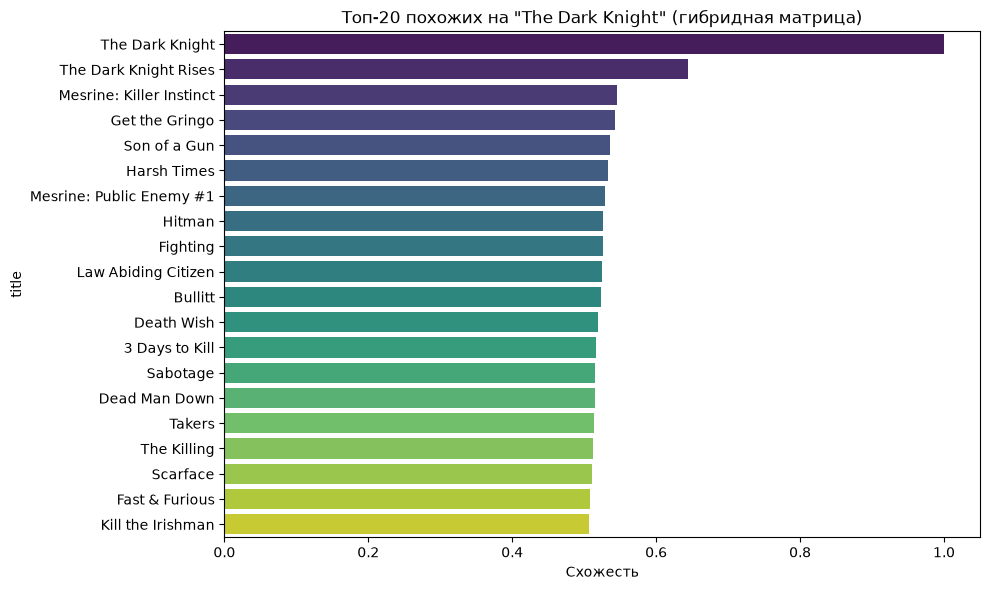

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Тепловая карта для одного фильма — с кем он похож
film = 'The Dark Knight'
sim_vector = item_sim_df_hybrid[film].sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=sim_vector.values, y=sim_vector.index, palette='viridis')
plt.title(f'Топ-20 похожих на "{film}" (гибридная матрица)')
plt.xlabel('Схожесть')
plt.tight_layout()
plt.show()

In [ ]:
# Сравним "чистоту" рекомендаций: гибрид vs только жанры vs только описания


def parse_genres(genres_str):
    try:
        genres_list = ast.literal_eval(genres_str)
        return " ".join([g['name'] for g in genres_list])
    except:
        return ""

movies['genres_clean'] = movies['genres'].apply(parse_genres)
print(f"Пример: {movies['genres_clean'].iloc[0]}")

def genre_purity(title, sim_df, top_n=10):
    orig_genres = movies.loc[movies['title'] == title, 'genres_clean'].values
    if len(orig_genres) == 0:
        return 0
    orig_set = set(orig_genres[0].split())
    
    recs = get_content_recommendations(title, sim_df, top_n)
    if recs is None:
        return 0
    
    matches = 0
    for rec_title in recs.index:
        rec_genres = movies.loc[movies['title'] == rec_title, 'genres_clean'].values
        if len(rec_genres) > 0:
            rec_set = set(rec_genres[0].split())
            if orig_set & rec_set:
                matches += 1
    
    return matches / top_n

print("\n=== Сравнение подходов по жанровой чистоте (исправлено) ===\n")
test_films = ['The Dark Knight', 'The Godfather', 'Pulp Fiction', 'Fight Club']

for film in test_films:
    g_purity = genre_purity(film, item_sim_df_content)
    o_purity = genre_purity(film, item_sim_df_overview)
    h_purity = genre_purity(film, item_sim_df_hybrid)
    
    purities = {'Жанры': g_purity, 'Описание': o_purity, 'ГИБРИД': h_purity}
    max_val = max(purities.values())
    
    # Считаем, сколько подходов показали максимум
    winners = [k for k, v in purities.items() if v == max_val]
    
    print(f"{film}:")
    for name, val in purities.items():
        # Помечаем "лучший" только если этот подход ЕДИНСТВЕННЫЙ с максимумом
        marker = "<- единственный лучший" if val == max_val and len(winners) == 1 else ""
        # Или помечаем всех победителей, но явно указываем ничью
        if val == max_val and len(winners) > 1:
            marker = f"<- ничья ({len(winners)} победителя)"
        print(f"  {name:10} {val:.0%}{marker}")
    print()


Пример: Animation Comedy Family

=== Сравнение подходов по жанровой чистоте (исправлено) ===

The Dark Knight:
  Жанры      100% ← ничья (3 победителя)
  Описание   100% ← ничья (3 победителя)
  ГИБРИД     100% ← ничья (3 победителя)

The Godfather:
  Жанры      100% ← ничья (2 победителя)
  Описание   80%
  ГИБРИД     100% ← ничья (2 победителя)

Pulp Fiction:
  Жанры      90% ← ничья (2 победителя)
  Описание   50%
  ГИБРИД     90% ← ничья (2 победителя)

Fight Club:
  Жанры      100% ← единственный лучший
  Описание   60%
  ГИБРИД     90%

